<a href="https://colab.research.google.com/github/CorinnnaZ/CompChallenge/blob/main/extension.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Extension
This is actually the extension. Only have 5 days to fully complete this which is fun ig.

### Part I: EyeBall
I would like to do geometric optics on an eye. Not for Andrew French's suggestion of the physics being analysed to help improve people's vision but focusing on raindrops and the refraction of white light in water.

All parameters of this should be accounted for since I want a visualisation - without any quantum effects - of Rayleigh Scattering, where shorter wavelength light scatter more than longer wavelength light.

I would like this to run as a simulation that can be pretty crudely analysed and demonstrated.

In [50]:
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as ipy
import random

 *Plot this as a non-dynamic plot and sort it out in a dynamic manner later.*

 **Goals:**
 - for each line that is on the left side of the circle, do the refraction thing
    - for the static diagram this will be manually adjusting the number "n" of lines that can be inputted

**Currently**:
*I have got this working as if it is a flat glass plane, which is unhelpful for my water  goals. Therefore, I will be added these things after the break:*
- adjusting calculations so it refracts as if in water
- calculating the emergent ray
- learning OOP again so that this can be done an n amount of times

***focus on these three bullet points***


There are two roots from this.
There is a chance that it is tangential, meaning the root is repeated.


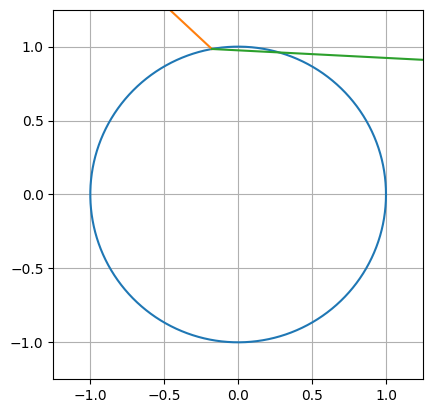

In [103]:
# plotting environment
fig, ax = plt.subplots()

# circle
t = np.arange(0, (2 * np.pi), 0.0025)

x = np.cos(t)
y = np.sin(t)

ax.plot(x,y)

# randomised line
m_1 = np.random.uniform(-1, 1) # gradient
y_1 = np.random.uniform(-1, 1) # y_intercept

a = (m_1 ** 2) + 1
b = (2 * m_1 * y_1)
c = (y_1 ** 2) - 1

### check discriminant
d = (b ** 2) - (4 * a * c)

### solve equation
x_values = []
if d < 0:
    print("There are no real solutions to this.\nOnly a circle will be plotted.")
elif d >= 0:
    print("There are two roots from this.\nThere is a chance that it is tangential, meaning the root is repeated.")
    x1 = (-b+np.sqrt(b**2-4*a*c))/(2*a)
    x2 = (-b-np.sqrt(b**2-4*a*c))/(2*a)
    x_values.extend([x1, x2])

min_x = min(x_values) # where the line first intersects the circle (from the left)

x_l = np.linspace(-5, min_x, 1000)
y_l = (m_1 * x_l) + y_1

ax.plot(x_l, y_l)
# refraction handling
n_1 = 1 # air
n_2 = 13.3 # water

theta_1 = np.arctan(m_1) # converts the initial randomised gradient into an angle
theta_2 = np.arcsin((n_1 / n_2) * np.sin(theta_1))  # Correct Snell's law

m_2 = np.tan(theta_2) # gradient of refracted ray
x_i, y_i = min_x, ((m_1 * min_x) + y_1) # intersection points of incident line and circle

x_r = np.linspace(x_i, 10, 1000) # I will calculate the emergent point later
y_r = m_2 * (x_r - x_i) + y_i

ax.plot(x_r, y_r)
# emergence handling

# plotting parameters
ax.set_xlim(-1.25, 1.25)
ax.set_ylim(-1.25, 1.25)
ax.set_aspect(1)
ax.grid()

#ax.legend()

## now try to put this into a class where I can change n and automatically 15 lines do this

### Part II: Classes & Boids
The detailed model of the one *EyeBall* can then be "extrapolated" onto an n-number of raindrops where an array of white light can be shone onto the environment and these reactions can take place to show what is happening

In [8]:
import numpy as np
import matplotlib.pyplot as plt

In [10]:
class Ray:
    def __init__(self, position, direction, wavelength, intensity):
        self.position = (position[0], position[1]) # starting vector position on the map

        self.direction = (direction[0], direction[1])  # to be vectorised to make later calcuations easier
                                                       # nonetheless, they will have to be parametrised for easier handling

        self.wavelength = wavelength # metres

        # what is the need for intensity? why is that important

class RainDrop:
    def __init__(self, centre, radius):
        # What geometric properties do you need?
        self.centre = (centre[0], centre[1]) # this will be updated with the collision aspect of it. To be implemented later
        self.radius = radius

    def equation_for_raindrop(self, centre, radius):
        # probably parametrically plot these points so that everything works together properly
        return None

    def get_refractive_index(self, wavelength):
        # wavelength are inputted in metres
        # currently using emperical values for this equation
        c = 3e8
        w = wavelength * 1e-9 # convert nanometre input into metres
        f = c / w
        n = np.sqrt(1 + (np.sqrt(1/(1.731 - 0.261 * ((f/1e15) ** 2)))))
        return n

    def find_intersection(self, ray):
        xr, yr = ray.position # starting point of ray
        dx, dy = ray.direction # to be parametrised into its gradient
        xc, yc = self.centre
        r = self.radius
        """
        How would I know
        # how would I know which intersection point to choose
        # to begin with I could just choose the one with the minimum x value
        # since everything was shining from left to right
        # this will not be the case later on
        """
        return intersection_point

    def refraction_direction(self, intersection_point):
        if intersection_point is None:
            intersection_point = find_intersection(self, ray)
        else:
            # calculation with this knowledge


rain = RainDrop((1,3), 17)
refractive = rain.get_refractive_index(400)
print(refractive)

1.3395914062982586


### Part III: Data Analysis
*Unironically might spend time after this trying to clean it up*

Something simple that can help to visualise the messiness of this 8GB laptop. Maybe the visual aspect is neglected and instead I have graphs that show the instance of frequencies of light (indicating each of the 8(?) colours of the rainbow) that will hopefully rest on shorter wavelengths.

Then, in the video, I can say that the use of abstractions like this can help physicists to see whether experiments are first worth pursuing and are helpful in explaining concepts at a higher level.